<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Day9/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [275]:
import pandas as pd
df = pd.read_csv('/content/Coal Consumption.csv',parse_dates=['Month'])

- parse_dates used to convert column type to datetime Type (ns --> nano secs)

In [276]:
df.shape

(132, 4)

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Month          132 non-null    datetime64[ns]
 1   Amount         132 non-null    float64       
 2   Extract_month  132 non-null    int64         
 3   Extract Year   132 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 4.3 KB


In [278]:
df.set_index("Month",inplace=True)

In [279]:
df.head()

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990


In [280]:
# As we've set month as index, so that we can slice it easilt
df.loc["1990"]

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990
1990-06-01,8.63,6,1990
1990-07-01,12.37,7,1990
1990-08-01,11.53,8,1990
1990-09-01,9.47,9,1990


In [281]:
df.loc["01-1990"]

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.5,1,1990


In [282]:
# last term is included as it is label based
df.loc["01-1990":"05-1990"]

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990


In [283]:
# check missing values
df.isna().sum()

,0
Amount,0
Extract_month,0
Extract Year,0


## Check missing Values in TimeSeries Data

1. Check the frequency of data
2. Use as Frequency Function
   https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

In [284]:
df1  = df.asfreq("MS")
df.shape,df1.shape

((132, 3), (132, 3))

In [285]:
df1.isnull().sum()

,0
Amount,0
Extract_month,0
Extract Year,0


## Fill Missing Value In Case Of TimeSeries
- bfill (Back Fill) : fill the next day value in current day
  * ex Fill 20th June value in 19th June record
- ffill (Front Fill) : fill the previous value in current day

In [286]:
df.ffill(inplace=True) # Forward Fill Missing Values

In [287]:
df.fillna(method='ffill',inplace=True)

/tmp/ipykernel_998/4116506308.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


## Time Series Decompose

- Help Us Understand whether the model is Additive or Multiplicative

### Possible Errors:

- Decompose will give error in three cases
  1. When data is not Pandas Dataframe
  2. When Index of the Dataframe is not time
  3. Missing Values in the TimeSeries


- Note : When we get Error here Check above 3 options before applying any other solution

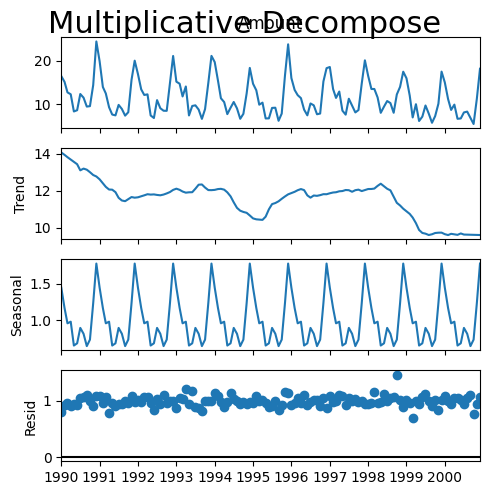

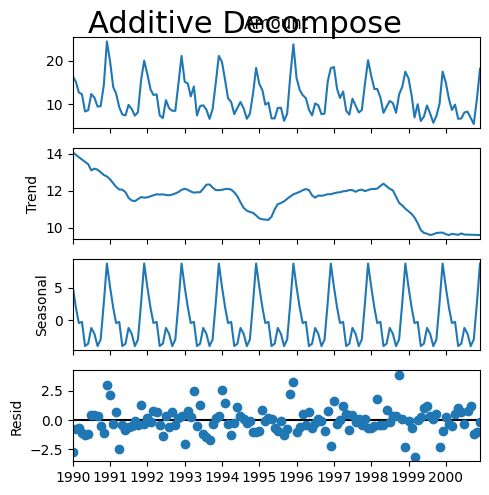

In [288]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
result_mul = seasonal_decompose(df['Amount'], model='multiplicative', extrapolate_trend='freq')

# Additive Decomposition
result_add = seasonal_decompose(df['Amount'], model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (5,5)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

## How do we decide whether Model is Additive or Multiplicative ?

- We Observe Residue of both the plots, Residue should be completely Random without any patterns



* Additive --> We may observe some pattern in residue
* Multiplicative --> Random Residue

## Check The Stationarity of Time Series

In [289]:
from statsmodels.tsa.stattools import adfuller
import random
random.seed(7)
# ADF Test
#Augmented Dickey–Fuller test
result = adfuller(df['Amount'].values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

#Failed to Reject H0 Hypothesis
# p_value > 0.05 (Not Stationary)

ADF Statistic: -1.7135083213470805
p-value: 0.42416636643258177
Critial Values:
   1%, -3.4870216863700767
Critial Values:
   5%, -2.8863625166643136
Critial Values:
   10%, -2.580009026141913


-  ADF test conclusion :: Failed to Reject H0 Hypothesis, p_value > 0.05
- TS is Non-Stationary we need to make it Stationary

In [290]:
df['lag1'] = df['Amount'].shift(1)

In [291]:
df['st'] = df['Amount'] - df['lag1']

In [292]:
df.head()

,Amount,Extract_month,Extract Year,lag1,st
Month,,,,,
1990-01-01,16.50,1,1990,NaN,NaN
1990-02-01,15.17,2,1990,16.50,-1.33
1990-03-01,12.75,3,1990,15.17,-2.42
1990-04-01,12.31,4,1990,12.75,-0.44
1990-05-01,8.34,5,1990,12.31,-3.97


In [293]:
from statsmodels.tsa.stattools import adfuller
import random
random.seed(7)
# ADF Test
#Augmented Dickey–Fuller test
result = adfuller(df['st'].values[1:], autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -3.902725577236599
p-value: 0.002014879672496045
Critial Values:
   1%, -3.487517288664615
Critial Values:
   5%, -2.8865777180380032
Critial Values:
   10%, -2.5801239192052012


## ADF Test on st Column Conclusion:
- Reject Null(H0) Hypothesis
- Data is Stationary
- Time Series data in 'st' column is stationary

# Apply Time Series Model

## Use pmdarima for ARIMA and SARIMA

In [294]:
!pip install pmdarima --quiet

In [295]:
import pmdarima as pm
from pmdarima.model_selection import train_test_split

In [296]:
y = df['Amount']
y.shape

(132,)

In [297]:
train, test = train_test_split(y, train_size=0.7)
train.shape, test.shape

((92,), (40,))

In [298]:
# Fit Your Model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      start_q=2,
                      max_q=20,
                      seasonal=True,
                      trace=True,
                      m=6,
                      random_state=7) #Seasonal -> True

Performing stepwise search to minimize aic
 ARIMA(5,0,2)(1,0,1)[6] intercept   : AIC=394.606, Time=6.21 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=527.476, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=474.251, Time=3.42 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=476.371, Time=0.78 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=728.231, Time=0.04 sec
 ARIMA(5,0,2)(0,0,1)[6] intercept   : AIC=456.694, Time=4.00 sec
 ARIMA(5,0,2)(1,0,0)[6] intercept   : AIC=409.569, Time=4.40 sec
 ARIMA(5,0,2)(2,0,1)[6] intercept   : AIC=inf, Time=8.09 sec
 ARIMA(5,0,2)(1,0,2)[6] intercept   : AIC=412.953, Time=5.56 sec
 ARIMA(5,0,2)(0,0,0)[6] intercept   : AIC=452.518, Time=4.98 sec
 ARIMA(5,0,2)(0,0,2)[6] intercept   : AIC=428.895, Time=5.05 sec
 ARIMA(5,0,2)(2,0,0)[6] intercept   : AIC=396.886, Time=3.36 sec
 ARIMA(5,0,2)(2,0,2)[6] intercept   : AIC=379.033, Time=4.47 sec
 ARIMA(4,0,2)(2,0,2)[6] intercept   : AIC=378.257, Time=1.54 sec
 ARIMA(4,0,2)(1,0,2)[6] intercept   : AIC=415.870, 

- check the minimum AIC value

In [299]:
# fit your ARIMA Model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      start_q=2,
                      max_q=20,
                      seasonal=False,
                      trace=True,
                      random_state=7)

Performing stepwise search to minimize aic
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=483.922, Time=1.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=728.231, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=501.905, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=633.168, Time=0.59 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=481.990, Time=2.95 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=480.126, Time=1.58 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=1.64 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=3.45 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=1.98 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=499.300, Time=0.47 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=3.07 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=494.520, Time=0.62 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=483.405, Time=1.67 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=471.700, Time=1.42 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=467.863, Time=3.83 se

## Set Value of d

In [300]:
# Fit SARIMA model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      d=1,
                      start_q=2,
                      max_q=20,
                      seasonal=True,
                      trace=True,
                      m=6,
                      random_state=7)

Performing stepwise search to minimize aic
 ARIMA(5,1,2)(1,0,1)[6] intercept   : AIC=381.241, Time=12.94 sec
 ARIMA(0,1,0)(0,0,0)[6] intercept   : AIC=495.719, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[6] intercept   : AIC=489.762, Time=0.67 sec
 ARIMA(0,1,1)(0,0,1)[6] intercept   : AIC=491.739, Time=0.83 sec
 ARIMA(0,1,0)(0,0,0)[6]             : AIC=493.758, Time=0.08 sec
 ARIMA(5,1,2)(0,0,1)[6] intercept   : AIC=inf, Time=4.92 sec
 ARIMA(5,1,2)(1,0,0)[6] intercept   : AIC=391.613, Time=5.97 sec
 ARIMA(5,1,2)(2,0,1)[6] intercept   : AIC=inf, Time=2.41 sec
 ARIMA(5,1,2)(1,0,2)[6] intercept   : AIC=364.028, Time=1.71 sec
 ARIMA(5,1,2)(0,0,2)[6] intercept   : AIC=inf, Time=1.14 sec
 ARIMA(5,1,2)(2,0,2)[6] intercept   : AIC=inf, Time=1.88 sec
 ARIMA(4,1,2)(1,0,2)[6] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(5,1,1)(1,0,2)[6] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(5,1,3)(1,0,2)[6] intercept   : AIC=inf, Time=4.29 sec
 ARIMA(4,1,1)(1,0,2)[6] intercept   : AIC=inf, Time=1.23 sec
 ARIMA(4,1,3)

In [301]:
# Fit ARIMA model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      d=1,
                      start_q=2,
                      max_q=20,
                      seasonal=False,
                      trace=True,
                      random_state=7)

Performing stepwise search to minimize aic
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=447.907, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=495.719, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=495.044, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=492.581, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=493.758, Time=0.02 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.50 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(6,1,2)(0,0,0)[0] intercept   : AIC=450.591, Time=0.75 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=489.479, Time=0.16 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(6,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(6,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(5,1,2)(0,0,0)[0]             : AIC=444.319, Time=2.68 sec
 ARIMA(4,1,2)(0,0,0)[0]             : AIC=inf, Time=0.82 sec
 ARIMA(5,1

## Check Performance for df 'st' column

In [302]:
y = df['st'][1:]
y.shape

(131,)

In [303]:
train, test = train_test_split(y, train_size=0.7)
train.shape, test.shape

((91,), (40,))

In [304]:
# Fit Your SARIMA Model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      start_q=2,
                      max_q=20,
                      seasonal=True,
                      trace=True,
                      m=6,
                      random_state=7)

Performing stepwise search to minimize aic
 ARIMA(5,0,2)(1,0,1)[6] intercept   : AIC=380.234, Time=1.11 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=495.719, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=489.762, Time=0.08 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=491.739, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=493.758, Time=0.02 sec
 ARIMA(5,0,2)(0,0,1)[6] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(5,0,2)(1,0,0)[6] intercept   : AIC=391.613, Time=1.01 sec
 ARIMA(5,0,2)(2,0,1)[6] intercept   : AIC=inf, Time=1.67 sec
 ARIMA(5,0,2)(1,0,2)[6] intercept   : AIC=inf, Time=3.94 sec
 ARIMA(5,0,2)(0,0,0)[6] intercept   : AIC=448.116, Time=0.83 sec
 ARIMA(5,0,2)(0,0,2)[6] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(5,0,2)(2,0,0)[6] intercept   : AIC=inf, Time=1.39 sec
 ARIMA(5,0,2)(2,0,2)[6] intercept   : AIC=inf, Time=1.95 sec
 ARIMA(4,0,2)(1,0,1)[6] intercept   : AIC=inf, Time=0.92 sec
 ARIMA(5,0,1)(1,0,1)[6] intercept   : AIC=375.549, Time=1.04 sec
 ARIMA(5,0

In [305]:
# Fit Your ARIMA Model
model = pm.auto_arima(train,
                      start_p=5,
                      max_p=20,
                      start_q=2,
                      max_q=20,
                      seasonal=False,
                      trace=True,
                      random_state=7)

Performing stepwise search to minimize aic
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=443.996, Time=0.55 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=493.758, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=493.077, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=490.613, Time=0.03 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.38 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.52 sec
 ARIMA(6,0,2)(0,0,0)[0]             : AIC=448.576, Time=0.60 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=inf, Time=0.59 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=487.553, Time=0.08 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.48 sec
 ARIMA(6,0,1)(0,0,0)[0]             : AIC=inf, Time=0.49 sec
 ARIMA(6,0,3)(0,0,0)[0]             : AIC=inf, Time=0.59 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=448.116, Time=1.41 sec

Best model:  ARIMA(5,0,2)(0,0,0)[0]          
Total fit time: 5.776 seconds


In [306]:
from pmdarima.arima import ARIMA
ar = ARIMA((5,0,2), with_intercept=False)
ar.fit(train)
forecasts = ar.predict(test.shape[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

In [307]:
pd.DataFrame([test,forecasts])

,1997-09-01,1997-10-01,1997-11-01,1997-12-01,1998-01-01,1998-02-01,1998-03-01,1998-04-01,1998-05-01,1998-06-01,...,2000-03-01,2000-04-01,2000-05-01,2000-06-01,2000-07-01,2000-08-01,2000-09-01,2000-10-01,2000-11-01,2000-12-01
st,-1.56000,0.550000,6.120000,5.360000,-3.590000,-3.030000,0.000000,-1.950000,-3.550000,1.430000,...,-2.51000,1.22000,-3.270000,0.080000,1.390000,0.190000,-1.440000,-1.420000,5.840000,6.920000
Unnamed 0,-0.12206,2.061774,3.987536,1.736878,-0.551283,-1.262339,-0.883276,-1.382587,-2.216357,-2.021778,...,-1.01733,-1.61511,-1.772507,-1.455921,-0.773074,0.089003,0.917099,1.505363,1.698661,1.444598


In [308]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
print(f'RMSE : {root_mean_squared_error(test,forecasts)}')
print(f'MAE : {mean_absolute_error(test,forecasts)}')
print(f'R2 : {r2_score(test,forecasts)}')

RMSE : 2.793638879143346
MAE : 2.4372314229920518
R2 : 0.26437585692577426


In [309]:
sar = ARIMA((5,0,0),(1,0,1,6), with_intercept=True)
sar.fit(train)
forecasts = sar.predict(test.shape[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [310]:
pd.DataFrame([test,forecasts])

,1997-09-01,1997-10-01,1997-11-01,1997-12-01,1998-01-01,1998-02-01,1998-03-01,1998-04-01,1998-05-01,1998-06-01,...,2000-03-01,2000-04-01,2000-05-01,2000-06-01,2000-07-01,2000-08-01,2000-09-01,2000-10-01,2000-11-01,2000-12-01
st,-1.56000,0.550000,6.120000,5.360000,-3.590000,-3.030000,0.000000,-1.950000,-3.550000,1.430000,...,-2.510000,1.220000,-3.270000,0.080000,1.390000,0.190000,-1.44000,-1.420000,5.840000,6.92000
Unnamed 0,-1.30217,0.835217,6.719794,4.426517,-3.135985,-2.825267,-1.499861,-0.244447,-3.819125,-1.655556,...,-0.757405,-0.361223,-4.604571,-2.371523,3.020002,0.587697,-0.25677,0.473021,5.651436,3.27555


In [311]:
print(f'RMSE : {root_mean_squared_error(test,forecasts)}')
print(f'MAE : {mean_absolute_error(test,forecasts)}')
print(f'R2 : {r2_score(test,forecasts)}')

RMSE : 2.0691924358059297
MAE : 1.6649781131967845
R2 : 0.5964315505502412


### Work with non stationary 'Amount' column

- Linear Regression
- Polynomial features (degree 2) + Linear Regression
- Polynomial features (degree 2) + LASSO
- Polynomial features (degree 2) + RIDGE


### Work with Stationary st column

In [312]:
df.isna().sum()

,0
Amount,0
Extract_month,0
Extract Year,0
lag1,1
st,1


In [313]:
df['lag1'] = df['Amount'].shift(1)
df['lag2'] = df['Amount'].shift(2)
df['lag3'] = df['Amount'].shift(3)
df['lag4'] = df['Amount'].shift(4)
df['lag5'] = df['Amount'].shift(5)
df['lag6'] = df['Amount'].shift(6)

In [314]:
df.dropna(inplace=True)
df.shape

(126, 10)

In [315]:
df.head()

,Amount,Extract_month,Extract Year,lag1,st,lag2,lag3,lag4,lag5,lag6
Month,,,,,,,,,,
1990-07-01,12.37,7,1990,8.63,3.74,8.34,12.31,12.75,15.17,16.50
1990-08-01,11.53,8,1990,12.37,-0.84,8.63,8.34,12.31,12.75,15.17
1990-09-01,9.47,9,1990,11.53,-2.06,12.37,8.63,8.34,12.31,12.75
1990-10-01,9.57,10,1990,9.47,0.10,11.53,12.37,8.63,8.34,12.31
1990-11-01,14.44,11,1990,9.57,4.87,9.47,11.53,12.37,8.63,8.34


In [316]:
df.columns

Index(['Amount', 'Extract_month', 'Extract Year', 'lag1', 'st', 'lag2', 'lag3',
       'lag4', 'lag5', 'lag6'],
      dtype='object')

## Separate X & y
- X --> all lag Columns
- Y --> Amount column

In [317]:
X = df[['lag1','lag2','lag3','lag4','lag5','lag6']]
y = df['Amount']
X.shape,y.shape

((126, 6), (126,))

## Train-test Split

In [318]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((88, 6), (38, 6), (88,), (38,))

### Apply Linear Regression

In [319]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [320]:
print(f'RMSE : {root_mean_squared_error(y_test,y_pred)}')
print(f'MAE : {mean_absolute_error(y_test,y_pred)}')

RMSE : 3.0405584465668274
MAE : 2.3142176174811304


In [321]:
from sklearn.preprocessing import PolynomialFeatures
pf = PolynomialFeatures(degree=2)
X_train_pf = pf.fit_transform(X_train)
X_test_pf = pf.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_pf,y_train)
y_pred = lr.predict(X_test_pf)
print(f'RMSE : {root_mean_squared_error(y_test,y_pred)}')
print(f'MAE : {mean_absolute_error(y_test,y_pred)}')

RMSE : 2.7130374407941744
MAE : 1.9617420853363234


In [322]:
from sklearn.linear_model import Lasso,Ridge
lr = Lasso()
lr.fit(X_train_pf,y_train)
y_pred = lr.predict(X_test_pf)
print(f'RMSE : {root_mean_squared_error(y_test,y_pred)}')
print(f'MAE : {mean_absolute_error(y_test,y_pred)}')

RMSE : 3.1214303905082263
MAE : 2.293684248203563


In [323]:
rg = Ridge()
rg.fit(X_train_pf,y_train)
y_pred = rg.predict(X_test_pf)
print(f'RMSE : {root_mean_squared_error(y_test,y_pred)}')
print(f'MAE : {mean_absolute_error(y_test,y_pred)}')

RMSE : 2.722467565282643
MAE : 1.9901058619844612
